# Exercise - Simple Linear Regression



In this notebook you can check your understanding of linear regression and implement a linear regression model with scikit-learn by yourself. 




## Learning Objectives

At the end of this notebook, you should be able to: 
- Describe the relationship between two variables.
- Train a linear regression model with scikit-learn.
- Interpret the $R^2$ of a linear regression model.

## Question 1 



The scatter plots below show the relationship between height, diameter, and volume of timber in 31 felled black cherry trees. The diameter of the tree is measured 4.5 feet above the ground.  

<img src="assets/lin_reg_ex_1.png" width="600">  

**(a) Describe the relationship between volume and height of these trees.**

The relationship between volume and height appears to be weakly positive and linear. 
As height increases, volume tends to increase, but the relationship shows considerable scatter, suggesting height alone is not a strong predictor of volume.

**(b) Describe the relationship between volume and diameter of these trees.**

The relationship between volume and diameter appears to be strongly positive. 
As the diameter increases, the volume increases substantially. 
This relationship appears stronger than the height-volume relationship, with points far less scattered, suggesting diameter is a better predictor of volume than height.

**(c) Suppose you measured the height and diameter of another black cherry tree. Which of these variables would be better for predicting the wood volume of this tree using a simple linear regression model? Explain your reasoning.**

Diameter is the better predictor of wood volume when using simple linear regression. 
The scatter plot shows a stronger and more consistent relationship between diameter and volume, with noticeably less variability than in the alternative relationship.

## Question 2 

The file `utils.csv` in your data folder contains information about the average utility bills for homes of a particular size and the average monthly temperature.  

**(a) Load the data:**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [18]:
df = pd.read_csv("data/utils.csv")
df.head()

,Month,Average Bill,Average Monthly Temperature
0,Jan,148.5,38
1,Feb,136.5,45
2,Mar,117.0,49
3,Apr,91.5,57
4,May,82.5,69


**(b) Make a scatter plot of the data average bill vs average monthly temperature. Which variable would make the most sense as the response variable?**

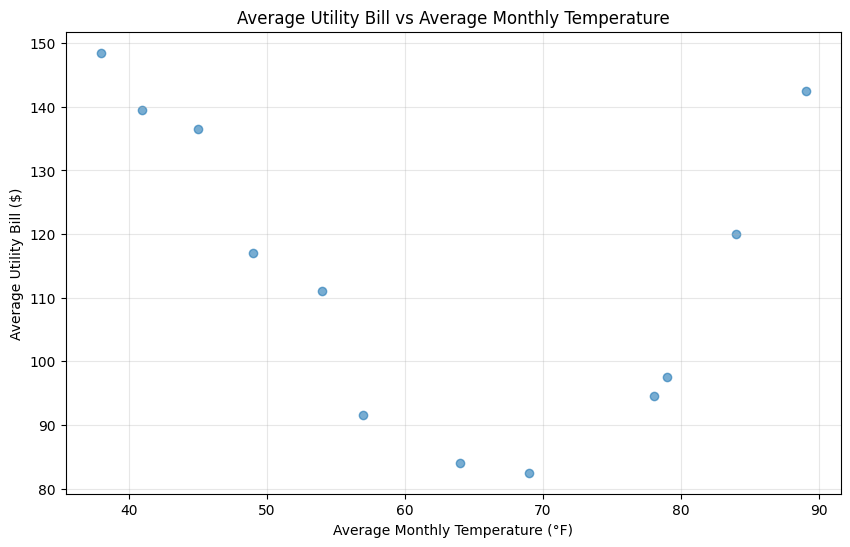

In [19]:
# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df["Average Monthly Temperature"], df["Average Bill"], alpha=0.6)
plt.xlabel("Average Monthly Temperature (°F)")
plt.ylabel("Average Utility Bill ($)")
plt.title("Average Utility Bill vs Average Monthly Temperature")
plt.grid(True, alpha=0.3)
plt.show()

Now, to determine which variable makes the most sense as the response variable, we need to consider the context of the data and the research question we want to answer. The response variable is the one that we are trying to predict or explain. Here are two possible scenarios:

- **Energy Consumption Analysis**: If we are trying to understand how "Average Bill" (energy consumption) changes with the variation in "Average Monthly Temperature," then "Average Bill" would be the response variable. In this case, we are interested in explaining energy consumption based on temperature changes.

- **Weather Impact Analysis**: If we are trying to understand how "Average Monthly Temperature" is affected by "Average Bill" (maybe heating or cooling expenses), then "Average Monthly Temperature" would be the response variable. In this case, we are interested in understanding how temperature is influenced by energy consumption. 
The second scenario is less common in practical applications, as temperature is typically considered an independent variable that influences energy consumption rather than the other way around. But it would make sense if we consider the temperature in a valley with a computing center. The higher the energy costs of this computing center, the higher the power consumption, the higher the temperature in the valley.

The choice of response variable depends on the research question and the specific analysis we want to perform.

**(c) Have a look at the plot above. How would you describe the relationship between the variables?** 

**Curvilinear Relationship:** If the points on the scatter plot form a curve (concave or convex), it indicates a curvilinear relationship. This means that the relationship between the variables is not a simple straight line, but rather follows a more complex curve.

**(d) Train a simple linear regression model using scikit-learn**

In [20]:
X = df[["Average Monthly Temperature"]]  # Input features (Independent variable)
y = df["Average Bill"]  # Target variable (Dependent variable)


# Create and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.48]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Average Monthly Temperature']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,143.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


**(e) Calculate and interpret the value of $R^2$.**  

In [21]:
from sklearn.metrics import r2_score

In [22]:
# Calculate R²
r2 = lr_model.score(X, y)
print(f"R² = {r2:.4f}")

# Or alternatively:
y_pred = lr_model.predict(X)
r2_alt = r2_score(y, y_pred)
print(f"R² (alternative calculation) = {r2_alt:.4f}")

R² = 0.1241
R² (alternative calculation) = 0.1241


An R-squared value close to 0 indicates that the model does not explain much of the variance in the target variable. It suggests that the model does not fit the data well or that the target variable is not strongly related to the input features.

**(f) Print the intercept and slope/coefficient and interpret them in terms a home owner would understand.**

In [23]:
# Print the coefficients and intercept of the model
print("Coefficients:", lr_model.coef_)
print("Intercept:", lr_model.intercept_)

Coefficients: [-0.47988442]
Intercept: 143.62280506779285


- Intercept (143.62): The intercept represents the value of the predicted target variable (in this case, "Average Bill") when the input feature (independent variable) is equal to zero. However, in this specific dataset, it may not have a practical interpretation because the "Average Monthly Temperature" cannot be zero in the real world.

- Coefficient (-0.47988): The coefficient represents the rate of change in the predicted target variable (again, "Average Bill") for each one-unit change in the input feature ("Average Monthly Temperature"). In this case, since the coefficient is negative (-0.47988), it suggests that as the "Average Monthly Temperature" increases by one unit, the "Average Bill" tends to decrease by approximately 0.47988 units.

**(g) Use your fitted model to estimate the average utility bill if the average monthly temperature is 120 degrees Fahrenheit. Do you think that your answer is reasonable? Why or why not?** 

In [24]:
avg_monthly_temp = 120
print(
    f"Average Monthly Bill is {lr_model.predict([[avg_monthly_temp]])[0]}, when Average Monthly Temperature is {avg_monthly_temp}"
)

Average Monthly Bill is 86.03667481662592, when Average Monthly Temperature is 120


d:\6- Data Science & AI neuefische GmbH\neuefische_bootcamp\week_05\ds-linear-regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


It's important to be cautious when interpreting predictions from a linear regression model, especially when making predictions beyond the range of the data used to train the model. The dataset used to train the model likely includes temperature values within a specific range, and extrapolating outside of this range might not be reliable.

In this case, the estimated average utility bill of approximately 86.03 when the average monthly temperature is 120 degrees Fahrenheit may not be reasonable for a few reasons:

- Extrapolation: The linear regression model is based on the observed data within the range of "Average Monthly Temperature" present in the dataset. Extrapolating the model to temperatures beyond this range might lead to less accurate predictions, as the relationship between temperature and utility bills might not be linear outside the observed range.

- Outliers: If the dataset used to train the model includes extreme or unusual data points, the model might not generalize well to extreme temperature values like 120 degrees Fahrenheit.

- Non-linearity: It's possible that the relationship between temperature and utility bills is not perfectly linear. In such cases, a linear model might not accurately capture the relationship.